In [7]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
shivamb_netflix_shows_path = kagglehub.dataset_download('shivamb/netflix-shows')

print('Data source import complete.')


Using Colab cache for faster access to the 'netflix-shows' dataset.
Data source import complete.


## Netflix EDA

In these uniquely challenging times, Netfilx has proven to be a great source of entertainment. The platform has recorded an increase of 23 percent in the number of paid members during the final quarters of 2020 when compared with the same period an year earlier.

Here is an exploratory data analysis done on the 'netflix-shows' dataset.

## Importing libraries

In [8]:
import numpy as np
import pandas as pd
from pandas import DataFrame

import missingno

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")

## Importing Data

In [9]:
import os
import pandas as pd
import zipfile
from pathlib import Path

kaggle_path = "/kaggle/input/netflix-shows/netflix_titles.csv"
if os.path.exists(kaggle_path):
    data = pd.read_csv(kaggle_path)

data


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## 1. Data Overview

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [11]:
data.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Text(0.5, 1.0, 'MISSING VALUES')

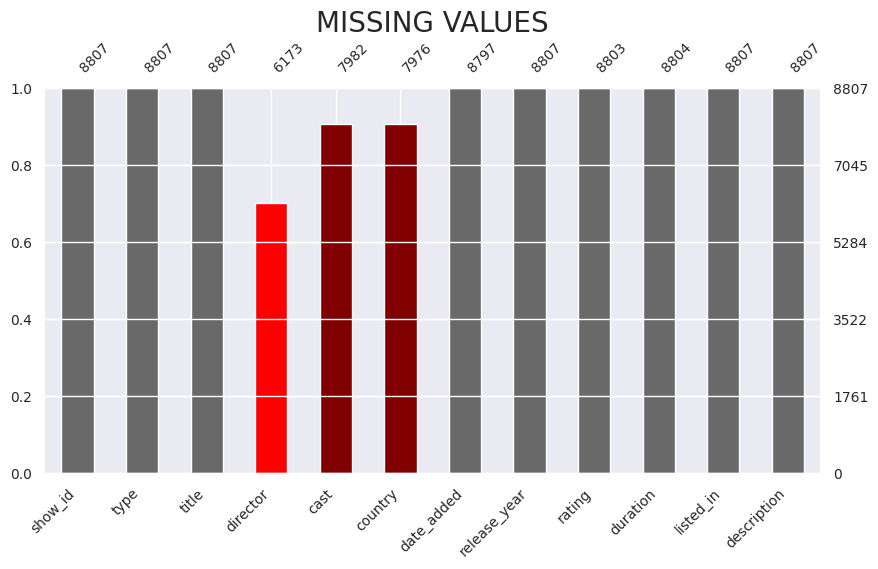

In [12]:
color= ['dimgrey','dimgrey','dimgrey','red','maroon','maroon','dimgrey','dimgrey','dimgrey','dimgrey','dimgrey','dimgrey']
missingno.bar(data,fontsize=10,color=color,figsize=(10,5))
plt.title('MISSING VALUES',fontsize=20)

As we can see, there are a lot of missing values in the director, cast and country columns. I will drop the director column as filling up the values will not be practically possible. Same for the cast column. For the country column, I am going to take the mode of available countries and assign it to the missing values. I will be doing the same for the date added and ratings column.

## MISSING VALUES

In [13]:
data['country'] = data['country'].fillna(data['country'].mode()[0])
data['date_added'] = data['date_added'].fillna(data['date_added'].mode()[0])
data['rating'] = data['rating'].fillna(data['country'].mode()[0])

In [14]:
data.drop(['cast','director'],axis='columns',inplace=True)

In [15]:
data.isna().sum()

,0
show_id,0
type,0
title,0
country,0
date_added,0
release_year,0
rating,0
duration,3
listed_in,0
description,0


Conclusion: All the missing values in the dataset have either been removed or filled. There are no missing values left.

In [16]:
data.duplicated().sum()

np.int64(0)

Conclusion: The dataset has 0 duplicated values.

## DATA CLEANING AND MANIPULATION

Adding some new columns:
* Year Added - y_add
* Month Added - m_add
* Princial Country - country_main
* Target Age Groups - target_age

In [17]:
data['y_add'] = data['date_added'].apply(lambda x: x.split(" ")[-1])
data['y_add'].head()

,y_add
0,2021
1,2021
2,2021
3,2021
4,2021


In [18]:
data['m_add'] = data['date_added'].apply(lambda x: x.split(" ")[0])
data['m_add'].head()

,m_add
0,September
1,September
2,September
3,September
4,September


In [19]:
ratings_ages = {
    'TV-PG': 'Older Kids',
    'TV-MA': 'Adults',
    'TV-Y7-FV': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-14': 'Teens',
    'R': 'Adults',
    'TV-Y': 'Kids',
    'NR': 'Adults',
    'PG-13': 'Teens',
    'TV-G': 'Kids',
    'PG': 'Older Kids',
    'G': 'Kids',
    'UR': 'Adults',
    'NC-17': 'Adults'
}
data['target_age'] = data['rating'].replace(ratings_ages)

In [20]:
data['country_main'] = data['country'].apply(lambda x: x.split(",")[0])
data['country_main'].head()

,country_main
0,United States
1,South Africa
2,United States
3,United States
4,India


Making two new dataframes, one with movies collection and other with TV shows collection:
* movie_df
* tv_df

In [21]:
movie_df = data[data['type'] == 'Movie']
tv_df = data[data['type'] == 'TV Show']

In [22]:
movie_df.head()

,show_id,type,title,country,date_added,release_year,rating,duration,listed_in,description,y_add,m_add,target_age,country_main
0,s1,Movie,Dick Johnson Is Dead,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,Teens,United States
6,s7,Movie,My Little Pony: A New Generation,United States,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,September,Older Kids,United States
7,s8,Movie,Sankofa,"United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,September,Adults,United States
9,s10,Movie,The Starling,United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,September,Teens,United States
12,s13,Movie,Je Suis Karl,"Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021,September,Adults,Germany


## Data Visualization

In [24]:
x = data['type'].value_counts().reset_index()
fig = px.pie(x,values='count',names='type',color_discrete_sequence=px.colors.sequential.RdBu)
fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker = dict(line = dict(color = 'white', width = 1)))

Conclusion: As we can see, the content on Netflix dataset has 30.4% TV shows and 69.6% Movies.

Now let's look into categorization based upon other factors.

In [26]:
country_df = data['country_main'].value_counts().reset_index()
country_df = country_df[country_df['count'] /  country_df['count'].sum() > 0.01]

fig = px.pie(country_df, values='count', names='country_main',color_discrete_sequence=px.colors.sequential.RdBu)
fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker = dict(line = dict(color = 'white', width = 1)))
fig.show()

Conclusion: After dividing the dataset on the basis of country of production, we see that United States holds the highest percentage, of about half of the total content. India comes second in the list with about 14 percentage share.
(Note: We have filled the NaN values in the country_main column with the mean() method. That can be counted as a factor of the dominance of United States)

In [27]:
def generate_df(df):
    new_df = df.groupby(['y_add', 'm_add']).agg({'show_id': 'count'}).reset_index()
    new_df = new_df[new_df['show_id'] != 0]
    new_df.columns = ['y_add', 'm_add', 'counts']
    new_df = new_df.sort_values('y_add')
    return new_df

In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

movie_new_df = generate_df(movie_df)
tv_new_df = generate_df(tv_df)

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "pie"}, {"type": "pie"}]])
fig.add_trace(
    go.Pie(labels=movie_new_df['y_add'], values=movie_new_df['counts']),
    row=1, col=1
)

fig.add_trace(
    go.Pie(labels=tv_new_df['y_add'], values=tv_new_df['counts']),
    row=1, col=2
)

fig.update_traces(textposition='inside', hole=.4, hoverinfo="label+percent+name",
                  marker = dict(line = dict(color = 'white', width = 2)))

fig.update_layout(
    title_text="Content distribution by Year of Adding",
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Movies', x=0.18, y=0.5, font_size=17, showarrow=False, font_color='black'),
                 dict(text='TV Shows', x=0.83, y=0.5, font_size=17, showarrow=False, font_color='black')])
fig.show()

Conclusion: The above plot shows the distribution of Movies and TV Shows separately based upon the year of adding. There is a noticable increase in the number of shows added throughout the years. For movies 2019 records the maximum number while for TV shows the year 2020 records the maximum number of addition of shows.

In [29]:
def generate_year_df(df,year):
    new_df = df.groupby(['target_age', 'y_add']).agg({'show_id': 'count'}).reset_index()
    new_df = new_df[new_df['show_id'] != 0]
    new_df.columns = ['target_age', 'y_add', 'counts']
    new_df = new_df.sort_values('y_add')
    new_df= new_df[new_df['y_add']==year]
    return new_df

In [36]:
fig = make_subplots(rows=1, cols=3, specs=[[{'type':'pie'}, {'type':'pie'}, {'type':'pie'}]],
                    subplot_titles=['2012', '2015', '2020'])

fig.add_trace(
    go.Pie(labels=group_2012['target_age'], values=group_2012['counts'],
           name="Target audience 2012",
           domain=dict(x=[0, 0.3], y=[0.1, 0.9])),  # ← force fixed domain
    1, 1)

fig.add_trace(
    go.Pie(labels=group_2015['target_age'], values=group_2015['counts'],
           name="Target audience 2015",
           domain=dict(x=[0.35, 0.65], y=[0.1, 0.9])),
    1, 2)

fig.add_trace(
    go.Pie(labels=group_2020['target_age'], values=group_2020['counts'],
           name="Target audience 2020",
           domain=dict(x=[0.7, 1.0], y=[0.1, 0.9])),
    1, 3)

fig.update_traces(
    textposition='inside',
    hoverinfo="label+percent+name",
    marker=dict(line=dict(color='white', width=1),
                colors=['#3D0C02', '#800000', '#C11B17', '#C0C0C0'])
)

fig.update_layout(title_text='Content distribution by target audience 2012 vs 2015 vs 2020')
fig.show()

Conclusion: The above plot shows content distribution by target age. The sizes of te plot is relative to the number of content added in the mentioned years. As it is clear from the plot, there was a huge increase in the number of content from the year 2012 to 2015 to 2020.

In [37]:
fig = px.histogram(data, x='country_main',color_discrete_sequence=['indianred'])
fig.update_xaxes(categoryorder='total ascending')
fig.show()

Conclusion: The above histogram represents the content added with respect to the country_main column.

In [38]:
def generate_age_df(df):
    new_df = df.groupby(['target_age']).agg({'show_id': 'count'}).reset_index()
    new_df = new_df[new_df['show_id'] != 0]
    new_df.columns = ['target_age', 'counts']
    new_df = new_df.sort_values('target_age')

    return new_df

In [39]:
movie_age_df = generate_age_df(movie_df)
fig = px.pie(labels = movie_age_df['target_age'], values = movie_age_df['counts'], names = movie_age_df['target_age'], width = 550, height = 550)

fig.update_traces(textposition = 'inside',
                  textinfo = 'percent + label',
                  hole = 0.75,
                  marker = dict(colors = ['#3D0C02', '#800000'  , '#C11B17','#C0C0C0'],
                                line = dict(color = 'white', width = 2)))

fig.update_layout(annotations = [dict(text = 'Movies',
                                      x = 0.5, y = 0.5, font_size = 40, showarrow = False,
                                      font_color = 'black')],
                  showlegend = False)

fig.show()

Conclusion: The above plot shows the percentage of movies added based upon the target age. As one can see, the Adults section scores the highest number with 48%.

In [40]:
tv_age_df = generate_age_df(tv_df)
fig = px.pie(labels = tv_age_df['target_age'], values = tv_age_df['counts'], names = tv_age_df['target_age'], width = 550, height = 550)

fig.update_traces(textposition = 'inside',
                  textinfo = 'percent + label',
                  hole = 0.75,
                  marker = dict(colors = ['#3D0C02', '#800000'  , '#C11B17','#C0C0C0'],
                                line = dict(color = 'white', width = 2)))

fig.update_layout(annotations = [dict(text = 'TV Series',
                                      x = 0.5, y = 0.5, font_size = 36, showarrow = False,
                                      font_color = 'black')],
                  showlegend = False)

fig.show()

Conclusion: The above plot shows the percentage of TV series added based upon the target age. As one can see, the Adults section scores the highest number with 43%.

<Axes: xlabel='release_year'>

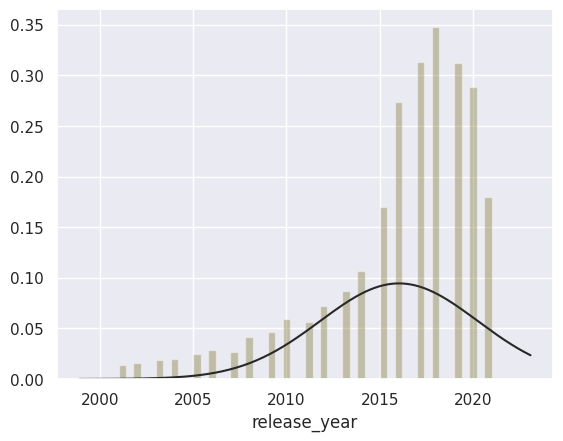

In [41]:
from scipy.stats import norm

sns.distplot(data.loc[data['release_year'] > 2000, 'release_year'],fit= norm, kde=False,
             color='#827839')

Conclusion: The above distplot is based upon the release_year of the movies/shows.

data.head()

In [42]:
def generate_duration_df(df):
    new_df = df.groupby(['duration']).agg({'show_id': 'count'}).reset_index()
    new_df = new_df[new_df['show_id'] != 0]
    new_df.columns = ['duration', 'counts']
    new_df = new_df.sort_values('duration')
    return new_df

In [43]:
new_movie_df = generate_duration_df(movie_df)
fig = px.bar(x=new_movie_df['duration'], y = new_movie_df['counts'])
fig.update_traces(marker = dict(color= '#FFA62F'))

fig.update_xaxes(type='category',categoryorder='total ascending')

fig.show()


Conclusion: The above plot is based upon the duration of Movies. As we can see, the duration of 90 minutes records the highest number of movies.

In [44]:
new_tv_df = generate_duration_df(tv_df)
fig = px.bar(x=new_tv_df['duration'], y = new_tv_df['counts'])
fig.update_traces(marker = dict(color= '#E55451'))
fig.update_xaxes(type='category',categoryorder='total ascending')
fig.show()


Conclusion: The above plot is based upon the seasons of TV series. As we can see, only 1 season records the highest number of Tv series. Discontinuation of shows due to less popularity or pending release of next season might be a contributing factor.|

In [45]:
def generate_country_df(df):
    new_df = df.groupby(['country_main']).agg({'show_id': 'count'}).reset_index()
    new_df = new_df[new_df['show_id'] != 0]
    new_df.columns = ['country_main', 'counts']
    new_df = new_df.sort_values('country_main')
    return new_df

In [47]:
tv_country_df = generate_country_df(tv_df)
fig = px.pie(labels = tv_country_df['country_main'], values = tv_country_df['counts'], names = tv_country_df['country_main'], width = 550, height = 550)

fig.update_traces(textposition = 'inside',
                  textinfo = 'percent + label',
                  hole = 0.75,
                  marker = dict(line = dict(color = 'white', width = 2)))

fig.update_layout(annotations = [dict(text = 'TV Series',
                                      x = 0.5, y = 0.5, font_size = 40, showarrow = False,
                                      font_color = 'black')],
                  showlegend = False)

fig.show()

Conclusion: Here is another pie plot depicting the percentage of TV series originating from a country. As noticed from the above, United States holds the highest percentage, i.e approx.46%.

In [48]:
movie_country_df = generate_country_df(movie_df)
fig = px.pie(labels = movie_country_df['country_main'], values = movie_country_df['counts'], names = movie_country_df['country_main'], width = 550, height = 550)

fig.update_traces(textposition = 'inside',
                  textinfo = 'percent + label',
                  hole = 0.75,
                  marker = dict(line = dict(color = 'white', width = 2)))


fig.update_layout(annotations = [dict(text = 'Movies',
                                      x = 0.5, y = 0.5, font_size = 32, showarrow = False,
                                      font_color = 'black')],
                  showlegend = False)

fig.show()

Conclusion: Here is another pie plot depicting the percentage of Movies originating from a country. As noticed from the above, United States holds the highest percentage, i.e approx.45.7%.

## ENDING NOTE:

This notebook is a compilation of my learnings from various articles/notebooks/tutorials. You might notice a slight resemblace in the way of creating function/plots as they have been inspired by the work of other more experienced people. However, I have tried to change and input my own ideations and variations. Constructive criticism is always welcome.

Attaching some of the inspiring works:
https://www.kaggle.com/dmitryuarov/netflix-eda-with-plotly#Distribution-of-main-genres-in-US,-India-and-Japan

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------